# 03_null_models

This notebook evaluates **null models** to verify that detected multiplicity hotspots
are **not artifacts** of the pipeline.

**Null hypothesis**

> Spatial clustering of prediction variance arises by chance.

**Null model**

* Model-wise permutation of predictions
* Preserve marginal prediction distributions
* Destroy observation-wise structure

## 1. Imports and paths

In [10]:
import sys
from pathlib import Path

# Add parent directory to path to import analysis module
# In Jupyter, cwd is usually the project root, but we check both
project_root = Path.cwd()
if not (project_root / 'analysis').exists():
    # If analysis/ not in cwd, try parent directory
    project_root = project_root.parent
sys.path.insert(0, str(project_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [11]:
from analysis.spatial import build_knn_graph, moran_global, lisa_local, extract_hh_components
from analysis.nulls import run_null_experiments, run_null_experiment

In [12]:
# Adjust this path to the experiment you want to analyze
# Path is relative to notebook location (notebooks/ directory)
BASE_PATH = Path("../results/compas/seed=42_eps=0.01")
assert BASE_PATH.exists(), f"Result directory not found: {BASE_PATH.absolute()}"

## 2. Load real experiment results

In [13]:
P = np.load(BASE_PATH / "P_test.npy")
metrics = np.load(BASE_PATH / "metrics.npz")
X_test = pd.read_csv(BASE_PATH / "X_test.csv")

In [14]:
v = metrics["variance"]

## 3. Spatial analysis on real data

In [15]:
# Use numeric features only for kNN
# (adjust if needed)
X_knn = X_test.select_dtypes(include=[np.number])

k = 10
W = build_knn_graph(X_knn, k=k)

In [16]:
moran_real = moran_global(v, W)
moran_real

{'I': 0.40761803236975563, 'p_value': 0.0}

In [17]:
lisa_real = lisa_local(v, W)
HH_real = lisa_real["cluster"] == "HH"

In [18]:
comp_id_real, comps_real = extract_hh_components(lisa_real, W)
print("#HH points (real):", HH_real.sum())
print("#HH components (real):", len(comps_real))

#HH points (real): 46
#HH components (real): 3


## 4. Run null experiments

In [19]:
from math import perm


null_df = run_null_experiments(
    P,
    X_knn,
    n_runs=10,
    permutations=100,
    k=k,
)

Running null experiment 1 of 10
Running null experiment 2 of 10
Running null experiment 3 of 10
Running null experiment 4 of 10
Running null experiment 5 of 10
Running null experiment 6 of 10
Running null experiment 7 of 10
Running null experiment 8 of 10
Running null experiment 9 of 10
Running null experiment 10 of 10


In [20]:
null_df.head()

,run,I,p_value
0,0,0.045273,0.90
1,1,0.046746,0.85
2,2,0.053127,0.69
3,3,0.046485,0.86
4,4,0.073577,0.10


## 5. Compare Moran's I: real vs null

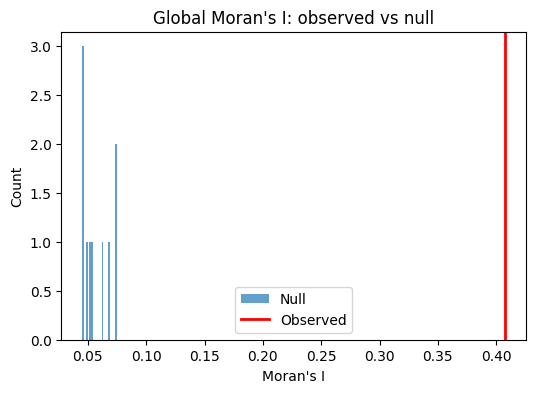

In [21]:
plt.figure(figsize=(6, 4))
plt.hist(null_df["I"], bins=20, alpha=0.7, label="Null")
plt.axvline(moran_real["I"], color="red", linewidth=2, label="Observed")
plt.xlabel("Moran's I")
plt.ylabel("Count")
plt.legend()
plt.title("Global Moran's I: observed vs null")
plt.show()

In [25]:
p_empirical = (null_df["I"] >= moran_real["I"]).mean()
print("Empirical p-value:", p_empirical)

Empirical p-value: 0.0


## 6. Null LISA sanity check (single run)

In [ ]:
# Pick one null run for illustration
null_example = run_null_experiment(P, X_knn, k=k, seed=123)
lisa_null = null_example["lisa"]

In [24]:
lisa_null["cluster"].value_counts()

cluster
NS    1442
HH       1
Name: count, dtype: int64